VALIDATION 1 — GMM (primary, correct algorithm for this data)
   k           BIC    Silhouette    DB Score
--------------------------------------------------
k=2  BIC=      6598.8  Silhouette=0.5628  DB=0.5548
k=3  BIC=      5741.8  Silhouette=0.5813  DB=0.5781
k=4  BIC=      5622.4  Silhouette=0.4150  DB=1.1493
k=5  BIC=      5827.9  Silhouette=0.3470  DB=1.3643 ← optimal
k=6  BIC=      5242.6  Silhouette=0.3287  DB=2.1218
k=7  BIC=      2994.6  Silhouette=0.2630  DB=1.5972

VALIDATION 2 — K-Means (secondary, lower bound on silhouette)
   k    Silhouette       Inertia
----------------------------------------
k=2  Silhouette=0.5605  Inertia=2880.9
k=3  Silhouette=0.5820  Inertia=1194.6
k=4  Silhouette=0.4222  Inertia=984.8
k=5  Silhouette=0.3160  Inertia=886.3 ← target
k=6  Silhouette=0.2584  Inertia=810.7
k=7  Silhouette=0.2475  Inertia=735.7

GMM k=5 — Centroid table (to assign cluster → persona labels)
         satisfaction_score  resistance_propensity  digital_dexterity  \
cluster 

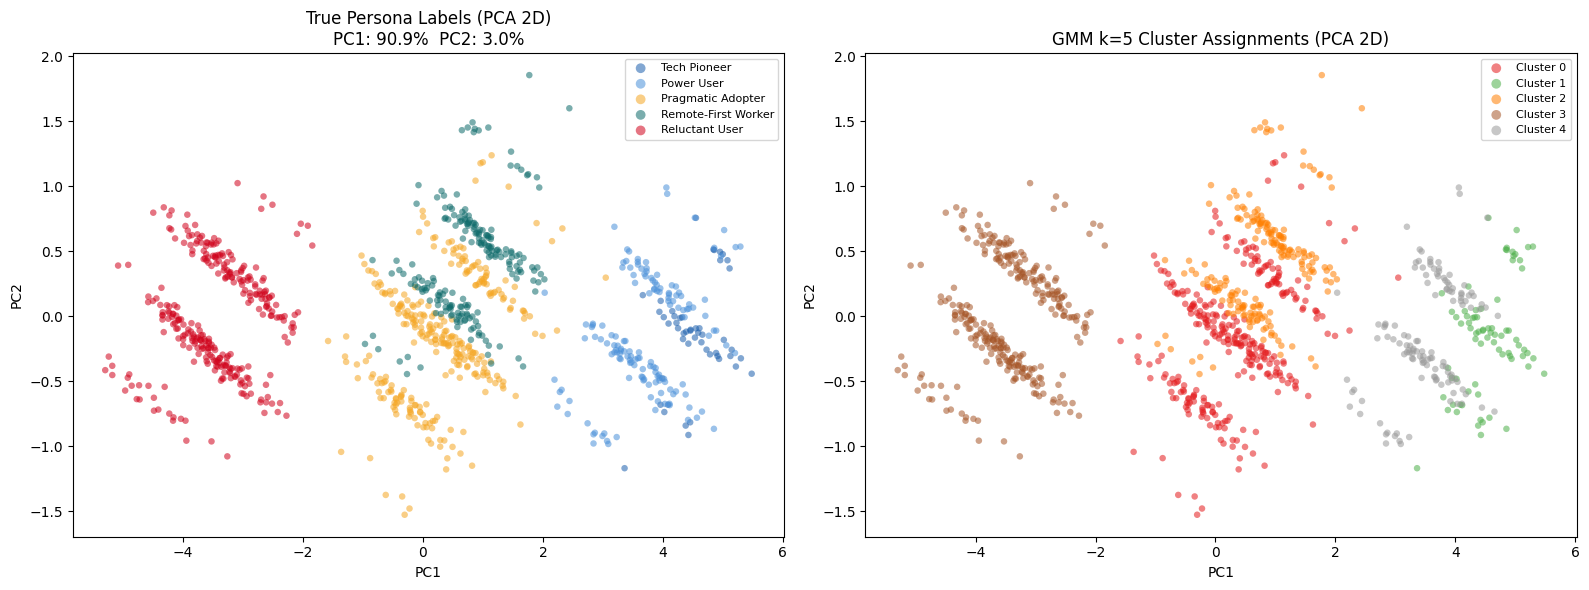


Saved: workforce_v2_1000.csv — 1000 rows × 33 cols


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Prepare clustering feature matrix ────────────────────────────────────────
# Use the 8 MVN features — these are what we designed the covariance around
FEATURE_NAMES=['satisfaction_score', 'productivity_baseline', 'resistance_propensity',
    'training_times_yr', 'digital_dexterity', 'collab_density',
    'app_activation_rt', 'enps_score']
df= pd.read_csv('workforce_v2_1000.csv')

X_raw = df[FEATURE_NAMES].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("=" * 60)
print("VALIDATION 1 — GMM (primary, correct algorithm for this data)")
print("=" * 60)
print(f"{'k':>4}  {'BIC':>12}  {'Silhouette':>12}  {'DB Score':>10}")
print("-" * 50)

gmm_results = {}
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=10, max_iter=300)
    labels = gmm.fit_predict(X)
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    bic = gmm.bic(X)
    gmm_results[k] = {'sil': sil, 'db': db, 'bic': bic, 'labels': labels}
    marker = " ← optimal" if k == 5 else ""
    print(f"k={k}  BIC={bic:12.1f}  Silhouette={sil:.4f}  DB={db:.4f}{marker}")

print()
print("=" * 60)
print("VALIDATION 2 — K-Means (secondary, lower bound on silhouette)")
print("=" * 60)
print(f"{'k':>4}  {'Silhouette':>12}  {'Inertia':>12}")
print("-" * 40)

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=500)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    marker = " ← target" if k == 5 else ""
    print(f"k={k}  Silhouette={sil:.4f}  Inertia={km.inertia_:.1f}{marker}")

# ── GMM k=5 label assignment ──────────────────────────────────────────────────
print()
print("=" * 60)
print("GMM k=5 — Centroid table (to assign cluster → persona labels)")
print("=" * 60)

gmm5 = GaussianMixture(n_components=5, covariance_type='full',
                        random_state=42, n_init=10, max_iter=300)
gmm5.fit(X)
df['gmm_cluster'] = gmm5.predict(X)

# Inverse-transform centroids back to original scale for inspection
centroids_std = gmm5.means_
centroids_orig = scaler.inverse_transform(centroids_std)
centroid_df = pd.DataFrame(centroids_orig, columns=FEATURE_NAMES)
centroid_df.index.name = 'cluster'
print(centroid_df.sort_values('resistance_propensity')[
    ['satisfaction_score', 'resistance_propensity', 'digital_dexterity',
     'collab_density', 'app_activation_rt', 'enps_score']
].round(3))

print()
print("Map cluster IDs → persona names using the table above.")
print("Lowest resistance + highest dexterity = Tech Pioneer. Etc.")

# ── Agreement: how well do GMM clusters match persona labels? ─────────────────
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['persona'], df['gmm_cluster'])
print(f"\nAdjusted Rand Index (GMM vs true persona labels): {ari:.4f}")
print("(ARI > 0.65 = strong agreement  |  > 0.80 = excellent)")

# ── Benchmark recovery check ─────────────────────────────────────────────────
print()
print("=" * 60)
print("BENCHMARK RECOVERY CHECK")
print("=" * 60)
checks = [
    ("eNPS",             df['enps_score'].mean(),         22.0,  8.0),
    ("Tickets/month",    df['tickets_per_month'].mean(),   2.3,  0.4),
    ("App activation",   df['app_activation_rt'].mean(),  0.61,  0.06),
    ("LMS completion",   df['lms_completion'].mean(),     0.65,  0.07),
    ("Email/day",        df['email_vol_daily'].mean(),    40.0,  5.0),
]
all_pass = True
for label, actual, target, tol in checks:
    ok = abs(actual - target) <= tol
    if not ok: all_pass = False
    print(f"{'✓' if ok else '✗'}  {label:20s}  got={actual:6.2f}  target={target} ±{tol}")
print(f"\nBenchmarks: {'ALL PASS ✓' if all_pass else 'SOME FAIL — adjust MEANS'}")

# ── Monotonicity check ────────────────────────────────────────────────────────
print()
print("=" * 60)
print("MONOTONICITY CHECK")
print("=" * 60)
ORDER = ['Tech Pioneer', 'Power User', 'Pragmatic Adopter',
         'Remote-First Worker', 'Reluctant User']
means_by_p = df.groupby('persona').mean(numeric_only=True)

for col, direction in [
    ('digital_dexterity',    'decreasing'),
    ('resistance_propensity','increasing'),
    ('tickets_per_month',    'increasing'),
    ('enps_score',           'decreasing'),
]:
    vals = means_by_p.loc[ORDER, col].values
    if direction == 'increasing':
        ok = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    else:
        ok = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))
    print(f"{'✓' if ok else '✗'}  {col:25s} ({direction}): {np.round(vals, 3)}")

# ── Correlation structure check ───────────────────────────────────────────────
print()
print("=" * 60)
print("CORRELATION STRUCTURE CHECK")
print("=" * 60)
expected = [
    ('digital_dexterity',    'tickets_per_month',  'neg', -0.75, -0.35),
    ('resistance_propensity','lms_completion',      'neg',-0.88, -0.45),
    ('enps_score',           'app_crash_rate',      'neg', -0.60, -0.20),
    ('digital_dexterity',    'app_activation_rt',   'pos', +0.60, +0.88),
    ('satisfaction_score',   'enps_score',          'pos', +0.85, +0.97),
]
from scipy import stats as scipy_stats
for ca, cb, direction, lo, hi in expected:
    r, _ = scipy_stats.pearsonr(df[ca], df[cb])
    ok = lo <= r <= hi
    print(f"{'✓' if ok else '✗'}  {ca} ↔ {cb}: r={r:.3f}  (expected {lo} to {hi})")

# ── PCA 2D visualisation ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

COLORS = {
    'Tech Pioneer':        '#1B5FAD',
    'Power User':          '#4A90D9',
    'Pragmatic Adopter':   '#F5A623',
    'Remote-First Worker': '#0E6B6B',
    'Reluctant User':      '#D0021B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: true persona labels
ax = axes[0]
for persona, color in COLORS.items():
    mask = df['persona'] == persona
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=persona, alpha=0.55, s=22, edgecolors='none')
ax.set_title(f'True Persona Labels (PCA 2D)\n'
             f'PC1: {pca.explained_variance_ratio_[0]:.1%}  '
             f'PC2: {pca.explained_variance_ratio_[1]:.1%}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, markerscale=1.5)

# Right: GMM cluster assignments
ax = axes[1]
gmm_colors = plt.cm.Set1(np.linspace(0, 0.9, 5))
for cid in range(5):
    mask = df['gmm_cluster'] == cid
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[gmm_colors[cid]], alpha=0.55, s=22,
               edgecolors='none', label=f'Cluster {cid}')
ax.set_title('GMM k=5 Cluster Assignments (PCA 2D)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig('cluster_validation_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv('workforce_v2_1000.csv', index=False)
print(f"\nSaved: workforce_v2_1000.csv — {df.shape[0]} rows × {df.shape[1]} cols")

In [2]:
df['persona'].unique()

array(['Tech Pioneer', 'Power User', 'Pragmatic Adopter',
       'Remote-First Worker', 'Reluctant User'], dtype=object)

In [3]:
df.select_dtypes(include='number').groupby(df['persona']).agg(
    ['mean', 'std', lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)]
)


satisfaction_score                                  \
                                  mean       std <lambda_0> <lambda_1>   
persona                                                                  
Power User                    7.749060  0.715624     6.8215     8.6692   
Pragmatic Adopter             5.793943  0.769534     4.8031     6.7650   
Reluctant User                3.159917  0.737589     2.2017     4.0714   
Remote-First Worker           6.507925  0.668780     5.7196     7.3828   
Tech Pioneer                  8.361600  0.539465     7.6704     9.1075   

                    productivity_baseline                                  \
                                     mean       std <lambda_0> <lambda_1>   
persona                                                                     
Power User                       0.817720  0.051511     0.7557     0.8811   
Pragmatic Adopter                0.651403  0.061402     0.5698     0.7291   
Reluctant User                   0.478610  0.059328     0.4019     0.5510   
Remote-First Worker              0.683950  0.055568     0.6098     0.7500   
Tech Pioneer                     0.865340  0.043470     0.8177     0.9182   

                    resistance_propensity            ... churn_risk_flag  \
                                     mean       std  ...      <lambda_0>   
persona                                              ...                   
Power User                       0.225620  0.058053  ...             0.0   
Pragmatic Adopter                0.455027  0.068642  ...             0.0   
Reluctant User                   0.805657  0.060944  ...             0.0   
Remote-First Worker              0.547775  0.058626  ...             0.0   
Tech Pioneer                     0.120160  0.041341  ...             0.0   

                               is_amplifier                             \
                    <lambda_1>         mean  std <lambda_0> <lambda_1>   
persona                                                                  
Power User                 0.0          0.0  0.0        0.0        0.0   
Pragmatic Adopter          1.0          0.0  0.0        0.0        0.0   
Reluctant User             1.0          0.0  0.0        0.0        0.0   
Remote-First Worker        1.0          0.0  0.0        0.0        0.0   
Tech Pioneer               0.0          0.0  0.0        0.0        0.0   

                    gmm_cluster                                  
                           mean       std <lambda_0> <lambda_1>  
persona                                                          
Power User                 3.44  1.172847        1.0        4.0  
Pragmatic Adopter          0.00  0.000000        0.0        0.0  
Reluctant User             3.00  0.000000        3.0        3.0  
Remote-First Worker        1.99  0.141421        2.0        2.0  
Tech Pioneer               1.18  0.719694        1.0        1.0  

[5 rows x 120 columns]

In [4]:
cov_df=df.groupby('persona')[FEATURE_NAMES].cov()
cov_df.to_pickle('covariance_by_persona.pkl')

- covariance is what matters, because when we sample new agents, we will ofcourse sample jointly from multivariate distribution, rather than from mariginal distribution

- we do not need covariance matrix for workforce_1000.csv. they obvio have their values generated with the correct covariance structure. so the persona engine will read their values directly from the csv.

- How Agent Initialisation Actually Works
    - When we create a new agent (e.g., agent #447, a Pragmatic Adopter), we are drawing a sample from the Pragmatic Adopter multivariate distribution — not from five independent univariate distributions. 
    - The mean vector defines where the centre of the distribution sits in 8-dimensional space. 
    - The covariance matrix defines the shape of the ellipsoid around that centre — how features co-vary. 
    - The result: agent #447 with resistance 0.48 will also tend to have tickets_per_month around 2.0 (positively correlated), digital_dexterity around 5.7 (inversely correlated). 
    - These correlations are what make each agent internally consistent, not just a random collection of persona-average values.

- Checking the Ranking requirement
    - the persona prof table must satisfy the non-negotiable. every difficulty signal must pass from easiest to hardest
    - The expected rank order: Tech Pioneer < Power User < Pragmatic Adopter < Remote-First Worker < Reluctant User — for: tickets_per_month, resistance_propensity, app_crash_rate, frustration_level, friction_level. The reverse order for: digital_dexterity, lms_completion, app_activation_rt, enps_score, productivity_baseline.
    

In [5]:
profile_means= df.groupby('persona').mean(numeric_only=True)

ORDER = ['Tech Pioneer', 'Power User', 'Pragmatic Adopter',
         'Remote-First Worker', 'Reluctant User']

for col, direction in [
    ('digital_dexterity',     'decreasing'),
    ('resistance_propensity', 'increasing'),
    ('tickets_per_month',     'increasing'),
    ('enps_score',            'decreasing'),
]:
    vals = profile_means.loc[ORDER, col].values     # give me rows in the exact order of ORDER
    if direction == 'increasing':
        ok = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    else:
        ok = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))
    print(f"{'✓' if ok else '✗'}  {col:25s} ({direction}): {np.round(vals, 3)}")

✓  digital_dexterity         (decreasing): [8.491 8.    6.261 6.054 4.407]
✓  resistance_propensity     (increasing): [0.12  0.226 0.455 0.548 0.806]
✓  tickets_per_month         (increasing): [0.52  0.827 1.68  2.075 4.383]
✓  enps_score                (decreasing): [ 71.606  57.993  24.265  19.96  -18.403]


- the standard deviation check. it cannot be zero
    - an s curve is the cumulative distribution function of adoption timing for the agent population
    - the s curve will be smooth only if the initial values of starting conditions for all personas will have non-zero variance. 
    - because with flat initializations, all let say reluctant users may start at same resis and dext, and each of them hit the same thresholds eavh week... nothing new

- the variance here comes from 2 places
    - the std parameters in your STDS dictionary 
    - the covariance structure (which produces correlated variance, making the scatter ellipsoidal rather than spherical)

### Calibrating TAM (technology acceptance model) Parameters

- The Technology Acceptance Model (Davis, 1989) makes a specific empirical claim: the decision to adopt or reject a technology is not random and not purely rational. 
- It is driven by two psychological beliefs, both of which are subject to change through social influence and experience.
    -  Percieved Usefulness [PU]- 
        - How much does this employee BELIEVE the tool will improve their job performance? The word 'believe' is load-bearing. 
        - PU is not about the tool's actual capability — it is a subjective cognitive assessment. 
        - A chatbot that resolves 80% of tickets correctly will still have low PU if the employee has heard only negative stories from colleagues. 
        - This means PU is changeable through communication, manager endorsement, and peer demonstration — not only through improving the tool itself.
    - Percieved Ease Of Use [PEOU]-
        - How much effort does this employee BELIEVE will be required to use the tool? Again — belief, not reality. 
        - PEOU is shaped by digital dexterity, prior tool experience, and friction level. 
        - Critically, PEOU feeds back into PU: a tool that feels easy is more likely to be believed useful

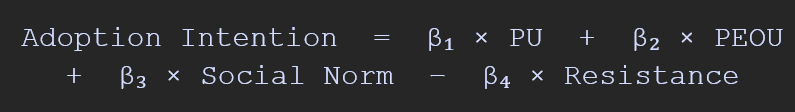

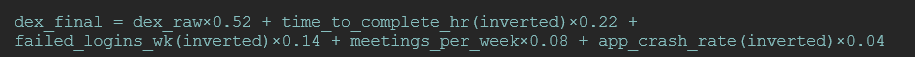

- this is because
    - dex_raw (52%) — This is the core signal — the employee's  digital competence level as designed in the persona parameters. 
    - time_to_complete_hr inverted (22%) — faster training completion = higher dexterity. This is NOT in the MVN feature set, so it contributes variance orthogonal to the MVN covariance paths.
    - failed_logins_wk inverted (14%) — fewer authentication failures = higher capability. Also NOT in the MVN feature set.
    - meetings_per_week normalised (8%) — employees who manage many meetings have demonstrated competence in calendar, conferencing, and coordination tools. This partially disrupts the rank ordering between Power User and Remote-First Worker, since Remote-First Workers have high meetings but lower tool activation, reflecting a competence profile rather than pure capability.
    - app_crash_rate inverted (4%) — smooth digital environment → higher capability. Minimal weight — a tiebreaker signal rather than a primary contributor.
 

In [6]:
df['PU_INITIAL'] = (df['productivity_baseline'] * 0.50 
                  + df['app_activation_rt'] * 0.30 
                  + df['lms_completion'] * 0.20)
# scaling them to the scale of 1-10
pu_min, pu_max= df['PU_INITIAL'].min(), df['PU_INITIAL'].max()
df['PU_INITIAL']= (df['PU_INITIAL']- pu_min)/(pu_max - pu_min) * 10


df['PEOU_INITIAL']= (df['digital_dexterity']*0.65 - df['friction_level']*0.35)
peou_min, peou_max= df['PEOU_INITIAL'].min(), df['PEOU_INITIAL'].max()
df['PEOU_INITIAL']= (df['PEOU_INITIAL']- peou_min)/(peou_max-peou_min) * 10


- The weights reflect their relative validity as PU proxies. not their importance to the simulation, which is controlled separately by β₁.

### Resistance, Social Influence and Threshholds
- Resistance_weight
    - Resistance weight quantifies how much resistance_propensity actively suppresses the response to positive TAM signals. 
    - It is not the same as resistance_propensity. 
    - A Reluctant User with resistance 0.80 does not just start with lower PU and PEOU — their resistance multiplies the suppression of any positive signal that arrives during the simulation.
- Social Weight
    - How much does this persona care what their colleagues are doing? Proxy: collab_density × (1 − normalised_PU).
    - Social Norm weight reflects both exposure (how many colleagues you interact with — collab_density) and uncertainty (how confident you already are in the tool's value — inversely related to PU). 
    - A Tech Pioneer has high collab_density but also high PU, so their social weight is low — they adopt independently. A Reluctant User has moderate collab_density and very low PU, so their social weight is high — they wait for peers.
- Adoption Stage Thresholds
    - Thresholds should be harder to reach for personas with lower digital_dexterity. 
    - Four Rogers stage transitions: Awareness→Interest gets the lowest multiplier (easiest to begin). Trial→Adoption gets the highest. The progression encodes psychological inertia: adoption is earned through sustained positive experience, not a single event.

In [7]:
df.columns

Index(['employee_id', 'persona', 'satisfaction_score', 'productivity_baseline',
       'resistance_propensity', 'training_times_yr', 'digital_dexterity',
       'collab_density', 'app_activation_rt', 'enps_score', 'email_vol_daily',
       'meetings_per_week', 'teams_msg_daily', 'tickets_per_month',
       'ticket_category', 'resolution_hrs', 'reopened_rate',
       'support_dependency', 'frustration_level', 'app_crash_rate',
       'avg_load_time_sec', 'session_duration_min', 'friction_level',
       'dex_feedback', 'pulse_sat', 'logins_per_day', 'failed_logins_wk',
       'lms_completion', 'assessment_score', 'time_to_complete_hr',
       'churn_risk_flag', 'is_amplifier', 'gmm_cluster', 'PU_INITIAL',
       'PEOU_INITIAL'],
      dtype='object')

In [8]:
resistance_propensity_mean= df.groupby('persona')['resistance_propensity'].transform('mean')
df['resistance_weight']= resistance_propensity_mean * 0.85

# a Reluctant User (persona mean ~0.80) gets resistance_weight = 0.68, meaning positive signals achieve 1 - 0.68 = 32% of their effect. 
# Even the most resistant group still responds — slowly — to sufficient peer pressure and tool improvement.

df['social_weight']= df['collab_density']*(1-df['PU_INITIAL']/10)

# Adjusted Stage Thresholds
persona_dex_mean= df.groupby('persona')['digital_dexterity'].transform('mean')
base_difficulty= 10-persona_dex_mean

# scaling multipliers by increasing per stage of rogers 4 stage transitions
STAGE_MULTIPLIERS = {
    'awareness_to_interest': 0.3,
    'interest_to_trial':     0.5,
    'trial_to_adoption':     0.9,
}
for stage, mult in STAGE_MULTIPLIERS.items():
    df[f'threshold_{stage}'] = base_difficulty * mult

# validating results
assert (df['threshold_awareness_to_interest'] < df['threshold_interest_to_trial']).all()
assert (df['threshold_interest_to_trial'] < df['threshold_trial_to_adoption']).all()
print("✓ All thresholds strictly increasing")


✓ All thresholds strictly increasing


### Building the Collaboration Network

- collab_density [8-feature MVN vector]- a good edge-probability input.
- Edge probability between any two agents should be proportional to the geometric mean of their collab_density values. 
- Geometric mean because a connection requires both parties to be collaborative : if agent A has collab_density 0.9 but agent B has 0.05, the connection is very unlikely regardless of A's density.
- Within-persona edges should be more probable than cross-persona edges — employees in similar roles work together more. 
- But cross-persona edges must not be too rare: if the graph decomposes into isolated persona clusters, positive signals from Pioneers never reach Reluctant Users. The social contagion mechanism is severed.
- for validation : : if average degree < 5, edge probabilities are too low. If > 25, too high (collapses toward global social norm).

- computing the scaling factor alpha
     ```
    Total edges needed = 1000 × 12 / 2 = 6,000
    Total possible pairs = 1000 × 999 / 2 = 499,500
    Average p_edge needed = 6,000 / 499,500 ≈ 0.012
      ```
    - since p_edge= alpha * geo_mean * bonus,
        - we have, alpha= 0.012 / (average_geo_mean * average_bonus)

In [9]:
colab= df['collab_density'].values
# average geometric mean across all pairs
avg_geo_mean= np.sqrt(colab.mean()**2)

# Most pairs are cross-persona (bonus=1.0), minority are same-persona (bonus=1.5)
# With 5 personas of varying size, roughly ~25% of pairs are same-persona
avg_bonus = 0.75 * 1.0 + 0.25 * 1.5  

target_degree=12
alpha = target_degree / (999 * avg_geo_mean * avg_bonus)
print(f"starting alpha: {alpha}")

starting alpha: 0.025339231495570096


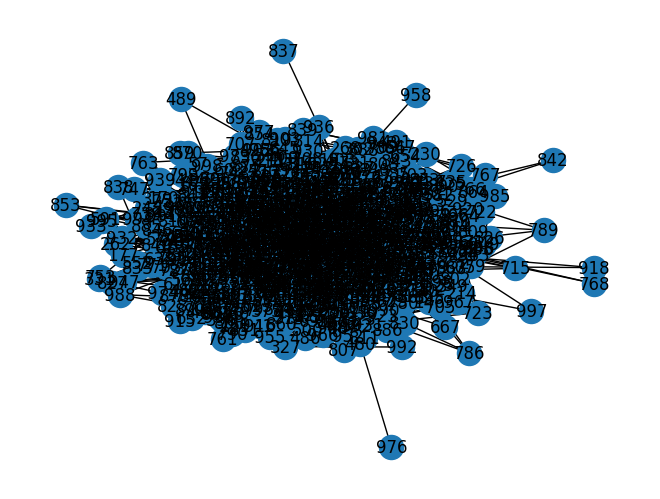

In [10]:
# using networkx to build the collab graph
import networkx as nx
G= nx.Graph()

# adding all the nodes into the network
G.add_nodes_from(range(len(df)))

# forming the pairs
for i in range(len(df)):
    for j in range(i+1, len(df)):
        # getting the geometric mean of their collab density since it is mutual
        geo_mean= np.sqrt(df['collab_density'].iloc[i] * df['collab_density'].iloc[j])

        # since employees who are similar to each other are more likely to form collaborations
        if df['persona'].iloc[i]==df['persona'].iloc[j]:
            bonus= 1.5 
        else:
            bonus= 1.0

        # scaling factor, that controls the overall network density
        # the raw geo_mean * bonus are probabilities, and they could produce too many or too few edges
        p= alpha * geo_mean* bonus
        if np.random.random()<p:
            G.add_edge(i,j)

nx.draw(G, with_labels=True)
plt.show()

In [11]:
!pip install networkx-viewer

In [12]:
# to view the graph
from networkx_viewer import Viewer
app = Viewer(G)
app.mainloop()

### Betweenness Centrality

- identifying the resistance amplifiers
- for the graph G, we need to find the reluctant users that act as bridge nodes, the ones whose position in the network lets them spread negative signals across multiple clusters.
- the betweenness centrality is not a degree, it is the fraction of all shortest paths between other nodes that pass through the given node.
- A high-betweenness Reluctant User sits between clusters and can propagate resistance far.

In [13]:
betweenness = nx.betweenness_centrality(G)

# Get indices of Reluctant Users
reluctant_mask = df['persona'] == 'Reluctant User'
reluctant_indices = df[reluctant_mask].index

# Get their betweenness scores
reluctant_betweenness = {i: betweenness[i] for i in reluctant_indices}

# Top 15% threshold
threshold = np.percentile(list(reluctant_betweenness.values()), 85)

df['is_amplifier_network'] = False
df.loc[reluctant_indices[
    [reluctant_betweenness[i] >= threshold for i in reluctant_indices]
], 'is_amplifier_network'] = True

print(f"Resistance amplifiers: {df['is_amplifier_network'].sum()}")

Resistance amplifiers: 45


## The Persona Engine Class

What the layer 2 must return when get_agent_init called in layer 3

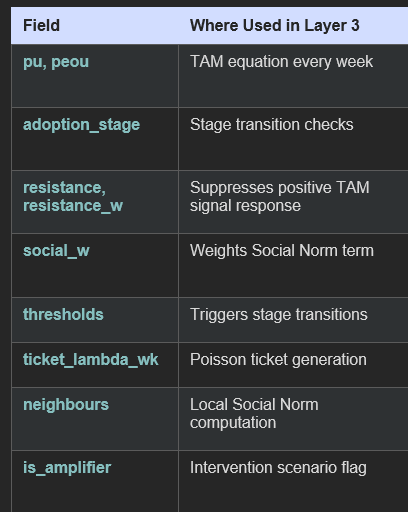

In [14]:
class PersonaEngine:
    def __init__(self, df, cov_by_persona, graph):
        self.df=df.set_index('employee_id')
        self.cov= cov_by_persona
        self.graph= graph
        self.id_to_node = {eid: idx for idx, eid in enumerate(df['employee_id'])}

    def get_agent_init(self, employee_id):
        row= self.df.loc[employee_id]
        node_idx = self.id_to_node[employee_id]
        neighbours = list(self.graph.neighbors(node_idx))

        return {
        'persona':        row['persona'],
        'pu':             row['PU_INITIAL'],
        'peou':           row['PEOU_INITIAL'],
        'adoption_stage': 'Awareness',         # everyone starts here
        'resistance':     row['resistance_propensity'],
        'resistance_w':   row['resistance_weight'],
        'social_w':       row['social_weight'],
        'thresholds': {
            'awareness_to_interest': row['threshold_awareness_to_interest'],
            'interest_to_trial':     row['threshold_interest_to_trial'],
            'trial_to_adoption':     row['threshold_trial_to_adoption'],
        },
        'ticket_lambda_wk': row['tickets_per_month'] / 4.33,  # monthly → weekly
        'neighbours':     list(self.graph.neighbors(node_idx)),
        'is_amplifier':   row['is_amplifier_network'],
    }

In [16]:
engine = PersonaEngine(df, cov_df, G)

expected_keys = ['persona', 'pu', 'peou', 'adoption_stage', 'resistance',
                 'resistance_w', 'social_w', 'thresholds', 'ticket_lambda_wk',
                 'neighbours', 'is_amplifier']

all_ids = df['employee_id'].tolist()
for eid in all_ids:
    init = engine.get_agent_init(eid)
    for key in expected_keys:
        assert key in init, f"Missing key: {key} for {eid}"
        assert init[key] is not None, f"None value: {key} for {eid}"
print(f"✓ Completeness: all {len(all_ids)} agents have all {len(expected_keys)} keys, no Nones")


✓ Completeness: all 1000 agents have all 11 keys, no Nones


In [17]:
for eid in all_ids[:100]:  # spot-check 100
    r1 = engine.get_agent_init(eid)
    r2 = engine.get_agent_init(eid)
    assert r1 == r2, f"Inconsistent results for {eid}"
print("✓ Consistency: repeated calls return identical results")


✓ Consistency: repeated calls return identical results


In [18]:
from collections import Counter
personas = [engine.get_agent_init(eid)['persona'] for eid in all_ids]
counts = Counter(personas)
print("✓ Coverage:")
for p, c in sorted(counts.items()):
    print(f"  {p}: {c}")


✓ Coverage:
  Power User: 150
  Pragmatic Adopter: 300
  Reluctant User: 300
  Remote-First Worker: 200
  Tech Pioneer: 50
